In [1]:
import pandas as pd

In [2]:
df =pd.read_csv('Dataset.csv')

In [3]:
df.head()

,batting_team,bowling_team,venue,current_score,is_powerplay,balls_left,wickets_left,current_run_rate,Top_Order,Middle_Order,Lower_Order,Tail,last_five,Death_Overs,final_score
0,South Africa,India,Johannesburg,171,0,15,7,9.771429,0,1,0,0,61,1,219
1,India,South Africa,Cape Town,66,0,71,9,8.081633,1,0,0,0,35,0,172
2,West Indies,Sri Lanka,Pallekele,120,0,9,6,6.486486,0,0,1,0,47,1,129
3,Australia,England,Melbourne,118,0,18,5,6.941176,0,0,1,0,38,1,147
4,South Africa,Sri Lanka,Johannesburg,69,0,56,5,6.468750,0,0,1,0,29,0,113


In [4]:
df['Pressure']= (df['current_run_rate'] <= 7.0).astype(int)

In [5]:
df.head()

,batting_team,bowling_team,venue,current_score,is_powerplay,balls_left,wickets_left,current_run_rate,Top_Order,Middle_Order,Lower_Order,Tail,last_five,Death_Overs,final_score,Pressure
0,South Africa,India,Johannesburg,171,0,15,7,9.771429,0,1,0,0,61,1,219,0
1,India,South Africa,Cape Town,66,0,71,9,8.081633,1,0,0,0,35,0,172,0
2,West Indies,Sri Lanka,Pallekele,120,0,9,6,6.486486,0,0,1,0,47,1,129,1
3,Australia,England,Melbourne,118,0,18,5,6.941176,0,0,1,0,38,1,147,1
4,South Africa,Sri Lanka,Johannesburg,69,0,56,5,6.468750,0,0,1,0,29,0,113,1


In [6]:
df['aggressive'] = (df['last_five'] >= 45).astype(int)

In [7]:
df.head()

,batting_team,bowling_team,venue,current_score,is_powerplay,balls_left,wickets_left,current_run_rate,Top_Order,Middle_Order,Lower_Order,Tail,last_five,Death_Overs,final_score,Pressure,aggressive
0,South Africa,India,Johannesburg,171,0,15,7,9.771429,0,1,0,0,61,1,219,0,1
1,India,South Africa,Cape Town,66,0,71,9,8.081633,1,0,0,0,35,0,172,0,0
2,West Indies,Sri Lanka,Pallekele,120,0,9,6,6.486486,0,0,1,0,47,1,129,1,1
3,Australia,England,Melbourne,118,0,18,5,6.941176,0,0,1,0,38,1,147,1,0
4,South Africa,Sri Lanka,Johannesburg,69,0,56,5,6.468750,0,0,1,0,29,0,113,1,0


In [8]:
df.isnull().sum()

batting_team        0
bowling_team        0
venue               0
current_score       0
is_powerplay        0
balls_left          0
wickets_left        0
current_run_rate    0
Top_Order           0
Middle_Order        0
Lower_Order         0
Tail                0
last_five           0
Death_Overs         0
final_score         0
Pressure            0
aggressive          0
dtype: int64

In [9]:
# Q1: Other than home ground, where did Sri Lanka play the most number of matches?

sl_matches = df[(df['batting_team'] == 'Sri Lanka') | (df['bowling_team'] == 'Sri Lanka')]

sl_venues = ['Colombo', 'Kandy', 'Hambantota', 'Pallekele', 'Dambulla', 'Moratuwa']

is_home = sl_matches['venue'].isin(sl_venues)
away_matches = sl_matches[~is_home]

venue_counts = away_matches['venue'].value_counts()

print(f"Most common away venue for Sri Lanka: {venue_counts.index[0]} with {venue_counts.values[0]} matches")

Most common away venue for Sri Lanka: Chittagong with 473 matches


In [10]:
# 2) Which Team has the highest score and opposition against which team did it occur?
highest_score= df['final_score'].max()

highest_score_row = df[df['final_score'] == highest_score].iloc[0]
batting_team = highest_score_row['batting_team']
bowling_team = highest_score_row['bowling_team']
venue = highest_score_row['venue']

print(f"Scored by: {batting_team}")
print(f"Against: {bowling_team}")
print(f"At: {venue}")

Scored by: Australia
Against: Sri Lanka
At: Pallekele


In [12]:
# 3) Which team has the highest run rate?

highest_run_rate= df['current_run_rate'].max()

teams_with_highest = df[df['current_run_rate'] == highest_run_rate]['batting_team'].tolist()

print(f"Highest run rate: {highest_run_rate}")
print(f"Teams with highest run rate: {teams_with_highest}")

Highest run rate: 16.6
Teams with highest run rate: ['New Zealand']


In [17]:
# 4) Which batting order (Top Order, Middle Order, Lower Order, or Tail) performed the best in
# terms of average runs scored?

batting_order = ['Top_Order', 'Middle_Order', 'Lower_Order', 'Tail']
average_runs = {}

for order in batting_order:
    # Filter rows where this order batted
    order_rows = df[df[order] == 1]
    # Take average of the final score
    average_runs[order] = order_rows['final_score'].mean()

# Convert to pandas Series for convenience
average_runs = pd.Series(average_runs).sort_values(ascending=False)

best_order = average_runs.idxmax()
best_avg = average_runs.max()

print("Average final score when each batting order batted:")
print(average_runs)
print(f"\nBest performing batting order: {best_order} with average final score {best_avg:.2f}")


Average final score when each batting order batted:
Top_Order       177.239031
Middle_Order    165.068978
Lower_Order     154.400451
Tail            139.503803
dtype: float64

Best performing batting order: Top_Order with average final score 177.24


In [18]:
# 5) What is the average pressure score in matches where the Tail was batting?
pressure_score = df[(df['Pressure'] == 1) & (df['Tail'] == 1)]['final_score'].mean()

print(f"Average final score when under pressure and Tail was batting: {pressure_score:.2f}")

Average final score when under pressure and Tail was batting: 119.38


In [21]:
# 6) In how many matches was the Aggression Mode set to 1? describe the teams with most
# aggressive Matches
aggressive_count = len(df[df['aggressive'] == 1])
print(f"Matches with Aggression Mode = 1: {aggressive_count}")

# Teams with most aggressive matches
print("\nTeams with most aggressive matches:")
print(df[df['aggressive'] == 1]['batting_team'].value_counts())



Matches with Aggression Mode = 1: 12639

Teams with most aggressive matches:
batting_team
New Zealand     1887
Australia       1878
Pakistan        1620
South Africa    1560
England         1439
India           1418
Sri Lanka       1169
West Indies     1146
Bangladesh       407
Afghanistan      115
Name: count, dtype: int64


In [22]:
# 7) What is the average runs scored by India in the last five overs (Death Overs) across all matches?
india_matches = df[df['batting_team'] == 'India']
avg_runs = india_matches['last_five'].mean()

print(f"Average runs scored by India in last five overs: {avg_runs:.2f}")


Average runs scored by India in last five overs: 39.65


In [23]:
# 8) Highest and Average score in Johannesburg?
Johannesburg = df[df['venue'] == 'Johannesburg']
highest_score =  Johannesburg['final_score'].max()
avg_score =  Johannesburg['final_score'].mean()

print(f"Highest score in Johannesburg: {highest_score}")
print(f"Average score in Johannesburg: {avg_score:.2f}")


Highest score in Johannesburg: 231
Average score in Johannesburg: 171.92


In [24]:
# 9) Highest and Average target set against Pakistan?
pakistan_bowling = df[df['bowling_team'] == 'Pakistan']

highest_target = pakistan_bowling['final_score'].max()
avg_target = pakistan_bowling['final_score'].mean()

print(f"Highest target set against Pakistan: {highest_target}")
print(f"Average target set against Pakistan: {avg_target:.2f}")

Highest target set against Pakistan: 211
Average target set against Pakistan: 150.05


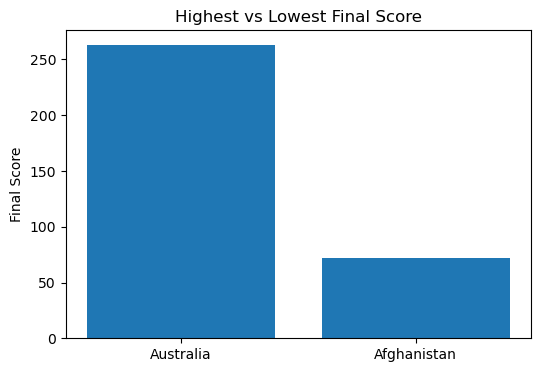

    batting_team  final_score
769    Australia          263
754  Afghanistan           72


In [25]:
# 10) Visualize the highest vs lowest score of a team.
import matplotlib.pyplot as plt

# Get highest and lowest scores
extremes = df.loc[
    [df['final_score'].idxmax(), df['final_score'].idxmin()],
    ['batting_team', 'final_score']
]

# Plot
plt.figure(figsize=(6, 4))
plt.bar(extremes['batting_team'], extremes['final_score'])
plt.ylabel('Final Score')
plt.title('Highest vs Lowest Final Score')
plt.show()

print(extremes)


In [26]:
# 11) Average Number of wickets fallen in death Overs?
death_overs_matches = df[df['Death_Overs'] == 1]
wickets_fallen = 10 - death_overs_matches['wickets_left']
avg_wickets_fallen = wickets_fallen.mean()

print(f"Average wickets fallen in death overs: {avg_wickets_fallen:.2f}")

Average wickets fallen in death overs: 4.94


In [27]:
# 12) Average target set by Pakistan in their homeland? Note: Homeland may include cities of Pakistan and UAE.
homeland_cities = ['Dubai', 'Abu Dhabi', 'Sharjah', 'Karachi', 'Lahore', 
                   'Rawalpindi', 'Multan', 'Faisalabad', 'Islamabad']

# Filter Pakistan batting at homeland venues
pakistan_homeland = df[(df['batting_team'] == 'Pakistan') & 
                       (df['venue'].isin(homeland_cities))]

avg_target = pakistan_homeland['final_score'].mean()

print(f"Average target set by Pakistan in homeland: {avg_target:.2f}")

Average target set by Pakistan in homeland: 151.81


In [28]:
# 13) describe the average runs scored by each team under pressure
pressure_matches = df[df['Pressure'] == 1]

# Calculate average runs under pressure for each team
avg_runs_under_pressure = pressure_matches.groupby('batting_team')['final_score'].mean().sort_values(ascending=False)

print("Average runs scored by each team under pressure:")
print(avg_runs_under_pressure)

Average runs scored by each team under pressure:
batting_team
India           143.835399
England         141.289332
Australia       141.271261
South Africa    140.006882
Bangladesh      133.959893
Sri Lanka       133.814639
West Indies     132.968238
Pakistan        132.388025
New Zealand     132.192270
Afghanistan     128.471025
Name: final_score, dtype: float64


In [29]:
# 14) describe the average runs scored by each team in death overs
deathover_matches = df[df['Death_Overs'] == 1]

avg_runs_death = deathover_matches.groupby('batting_team')['last_five'].mean().sort_values(ascending=False)

print("Average runs scored by each team in death overs:")
print(avg_runs_death)

Average runs scored by each team in death overs:
batting_team
Australia       45.073406
New Zealand     44.457064
India           44.302187
South Africa    43.536148
Pakistan        41.954711
England         41.442321
West Indies     40.587068
Sri Lanka       40.220967
Afghanistan     39.832700
Bangladesh      37.487903
Name: last_five, dtype: float64


In [30]:
# 15) describe the average target by each Team
avg_target = df.groupby('batting_team')['final_score'].mean().sort_values(ascending=False)

print("Average target set by each team:")
print(avg_target)

Average target set by each team:
batting_team
Australia       171.136252
India           166.511938
England         164.992529
New Zealand     164.138972
South Africa    163.846840
Sri Lanka       157.104880
West Indies     155.947454
Pakistan        155.922244
Bangladesh      150.069024
Afghanistan     133.361474
Name: final_score, dtype: float64


In [32]:
from sklearn.model_selection import train_test_split

X = df.drop('final_score', axis=1)  
y = df['final_score'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Train set size: (34546, 16)
Test set size: (8637, 16)


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression


num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),     
        ('cat', OneHotEncoder(), cat_cols)       
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())   
])




In [35]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
y_pred = pipeline.predict(X_test)

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MODEL PERFORMANCE")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

MODEL PERFORMANCE
MSE:  303.07
RMSE: 17.41
MAE:  12.85
R²:   0.7082


In [39]:
from sklearn.model_selection import train_test_split

X = df.drop('final_score', axis=1)  
y = df['final_score'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Train set size: (34546, 16)
Test set size: (8637, 16)


In [40]:
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [42]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
scaler = StandardScaler()

# Transform training data
X_train_num = scaler.fit_transform(X_train[num_cols])
X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_train_processed = np.hstack([X_train_num, X_train_cat])

# Transform test data (using fitted encoder/scaler)
X_test_num = scaler.transform(X_test[num_cols])
X_test_cat = encoder.transform(X_test[cat_cols])
X_test_processed = np.hstack([X_test_num, X_test_cat])

In [47]:
class MultivariateLinearRegression:
    def __init__(self):
        self.weights = None  
        self.bias = 0.0
        self.losses = []
    
    def predict(self, X):
        return X @ self.weights + self.bias  
    
    def compute_cost(self, X, y):
        m = len(X)
        errors = self.predict(X) - y
        return (1 / (2 * m)) * np.sum(errors ** 2)
    
    def fit(self, X, y, alpha=0.01, iterations=1000, verbose=True):
        m, n = X.shape   
        self.weights = np.zeros(n)
        self.bias = 0.0
        self.losses = []
        
        for i in range(iterations):
            y_pred = self.predict(X)
            errors = y_pred - y 
            dw = (1/m) * (X.T @ errors)
            db = (1/m) * np.sum(errors) 
            self.weights -= alpha * dw
            self.bias -= alpha * db
            
            cost = self.compute_cost(X, y)
            self.losses.append(cost)
            
            # Print progress
            if verbose and i % 100 == 0:
                print(f"Iteration {i}: cost = {cost:.4f}")
        
        return self
    
    def get_params(self):
        return {'weights': self.weights, 'bias': self.bias}


# Use your preprocessed cricket data
model = MultivariateLinearRegression()
model.fit(X_train_processed, y_train, alpha=0.01, iterations=1000)

# Predict
y_pred_test = model.predict(X_test_processed)

# Evaluate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("CRICKET SCORE PREDICTION - FROM SCRATCH")
print(f"Test R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_test):.2f}")


Iteration 0: cost = 13155.1118
Iteration 100: cost = 1221.5788
Iteration 200: cost = 282.1821
Iteration 300: cost = 201.2317
Iteration 400: cost = 190.4942
Iteration 500: cost = 186.4135
Iteration 600: cost = 183.5629
Iteration 700: cost = 181.2992
Iteration 800: cost = 179.4361
Iteration 900: cost = 177.8674
CRICKET SCORE PREDICTION - FROM SCRATCH
Test R²:   0.6636
Test RMSE: 18.69
Test MAE:  13.79


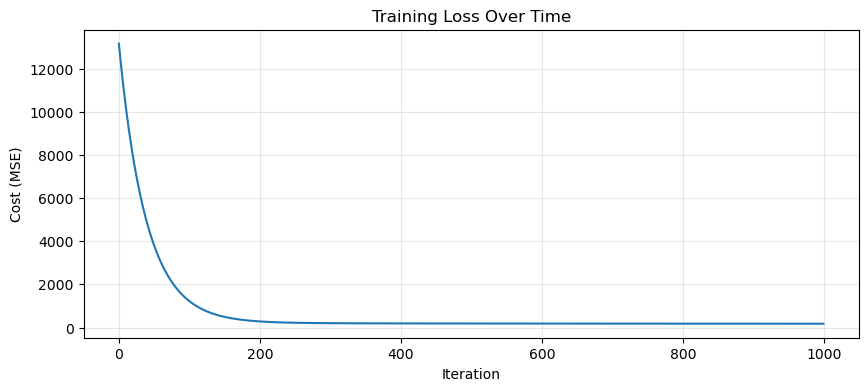

In [48]:
# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(model.losses)
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

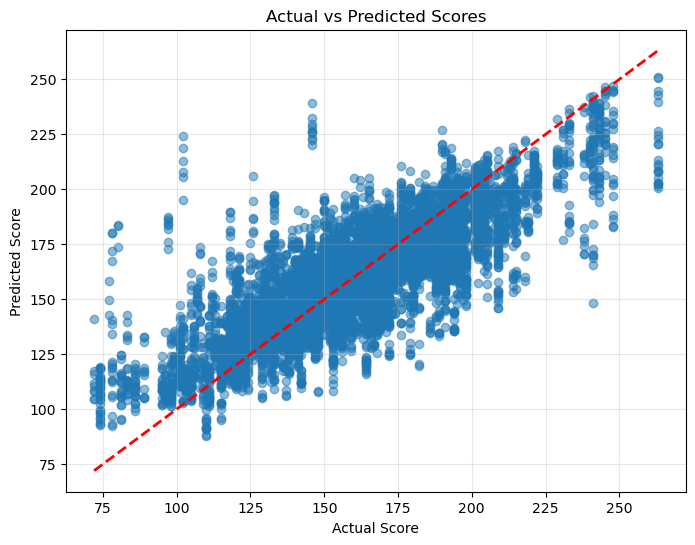

In [75]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs Predicted Scores')
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
print(" Adding 2 new features...")

# 1. Projected final score based on current run rate
df['projected_score'] = (df['current_run_rate'] * 20).round(0)

# 2. Wickets fallen (more intuitive than wickets_left)
df['wickets_fallen'] = 10 - df['wickets_left']
df.head()

 Adding 2 new features...


,batting_team,bowling_team,venue,current_score,is_powerplay,balls_left,wickets_left,current_run_rate,Top_Order,Middle_Order,Lower_Order,Tail,last_five,Death_Overs,final_score,Pressure,aggressive,projected_score,wickets_fallen
0,South Africa,India,Johannesburg,171,0,15,7,9.771429,0,1,0,0,61,1,219,0,1,195.0,3
1,India,South Africa,Cape Town,66,0,71,9,8.081633,1,0,0,0,35,0,172,0,0,162.0,1
2,West Indies,Sri Lanka,Pallekele,120,0,9,6,6.486486,0,0,1,0,47,1,129,1,1,130.0,4
3,Australia,England,Melbourne,118,0,18,5,6.941176,0,0,1,0,38,1,147,1,0,139.0,5
4,South Africa,Sri Lanka,Johannesburg,69,0,56,5,6.468750,0,0,1,0,29,0,113,1,0,129.0,5


In [52]:
X = df.drop('final_score', axis=1)
y = df['final_score']

# 2. RETRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. RECREATE PIPELINE with updated columns
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# 4. RETRAIN AND EVALUATE
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MODEL PERFORMANCE - WITH 3 NEW FEATURES")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

MODEL PERFORMANCE - WITH 3 NEW FEATURES
MSE:  303.06
RMSE: 17.41
MAE:  12.85
R²:   0.7082


In [57]:
# ============================================
# SINGLE PREDICTION
# ============================================

# Define ONE match scenario
single_match = pd.DataFrame([{
    'batting_team': 'Pakistan',
    'bowling_team': 'South Africa', 
    'venue': 'Dubai',
    'current_score': 110,
    'is_powerplay': 0,
    'balls_left': 48,
    'wickets_left': 5,
    'current_run_rate': 6.5,
    'Top_Order': 0,
    'Middle_Order': 1,
    'Lower_Order': 0,
    'Tail': 0,
    'last_five': 28,
    'Death_Overs': 1,
    'Pressure': 1,
    'aggressive': 0,
    'projected_score': 130,
    'wickets_fallen': 5
}])

# Ensure columns match training data
for col in X_train.columns:
    if col not in single_match.columns:
        single_match[col] = 0

single_match = single_match[X_train.columns]

# Predict
prediction = pipeline.predict(single_match)[0]

print("="*50)
print("SINGLE PREDICTION")
print("="*50)
print(f"Team: India vs Australia")
print(f"Current: 85/2 (5 overs)")
print(f"Run Rate: 8.5")
print(f"\n🔮 PREDICTED FINAL SCORE: {prediction:.0f}")
print(f"   Range: {prediction - rmse:.0f} - {prediction + rmse:.0f}")
print("="*50)

SINGLE PREDICTION
Team: India vs Australia
Current: 85/2 (5 overs)
Run Rate: 8.5

🔮 PREDICTED FINAL SCORE: 148
   Range: 130 - 165


In [59]:
# Use ONLY numeric columns (drop team/venue)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('final_score')  

X_numeric = df[numeric_cols]
y = df['final_score']

# Split
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
model_numeric = LinearRegression()
model_numeric.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model_numeric.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("MODEL WITH NUMERIC FEATURES ONLY")
print(f"Features: {len(numeric_cols)} numeric columns")
print(f"RMSE: {rmse:.2f}")
print(f"R²:  {r2:.4f}")
print(f"mae:  {mae:.4f}")

MODEL WITH NUMERIC FEATURES ONLY
Features: 13 numeric columns
RMSE: 18.74
R²:  0.6619
mae:  13.7323
